In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

## Load and Visualize the data

In [6]:
train_path = '../data/processed/train.npz'
test_path = '../data/processed/test.npz'

def load_data(npz_path):
    data = np.load(npz_path)
    signals = data['eeg_windows']
    contexts = data['context_windows']
    labels = data['labels']

    return signals, contexts, labels

signals, contexts, labels = load_data(train_path)

In [7]:
arousals = signals[labels == 1]
non_arousals = signals[labels == 0]

print("Arousal Events: ", arousals.shape)
print("Non Arousal Events: ", non_arousals.shape)

Arousal Events:  (8719, 2, 1500)
Non Arousal Events:  (8707, 2, 1500)


## View STFT Features 

In [8]:
idx = 0

[+] Visualizing Sample #0 | True Label: Arousal Onset Zone


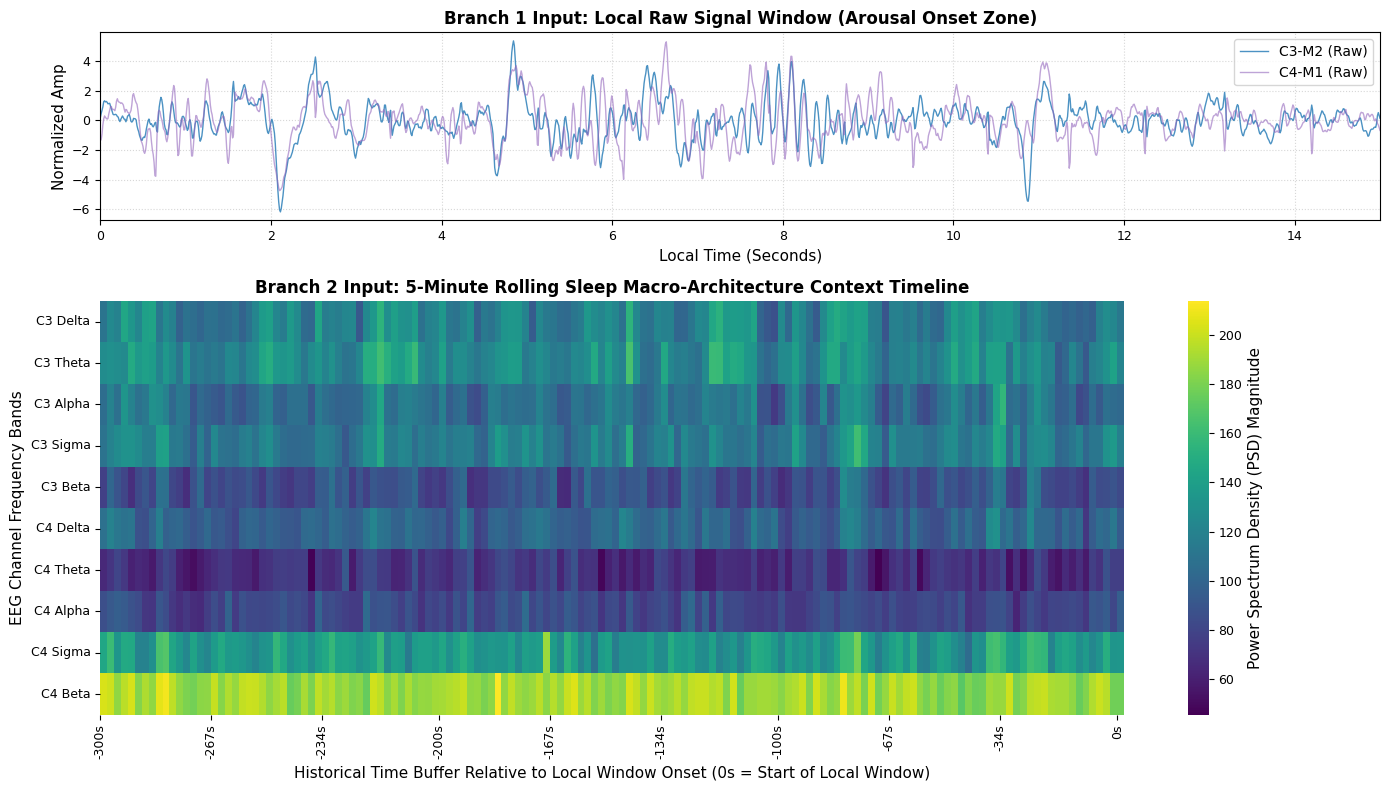

In [9]:
import seaborn as sns

# 2. Select a sample to inspect (Change this index to view different windows)
sample_idx = 0  
label_dict = {0: "No Arousal (Pure Sleep)", 1: "Arousal Onset Zone"}

# Isolate the sample components
raw_signal = signals[sample_idx]  # Shape: (2, 1500)
context_matrix = contexts[sample_idx]  # Shape: (148, 10)
sample_label = labels[sample_idx]

print(f"[+] Visualizing Sample #{sample_idx} | True Label: {label_dict[sample_label]}")

# 3. Create the multi-plot canvas
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [1, 2.2]})

# -----------------------------------------------------------------------------
# UPPER PLOT: Raw EEG Signal Branch (15 Seconds)
# -----------------------------------------------------------------------------
fs = 100  # Assumed 100Hz sampling rate
time_axis_local = np.linspace(0, 15, raw_signal.shape[1])

axes[0].plot(time_axis_local, raw_signal[0], label="C3-M2 (Raw)", color="tab:blue", alpha=0.8, linewidth=1)
axes[0].plot(time_axis_local, raw_signal[1], label="C4-M1 (Raw)", color="tab:purple", alpha=0.6, linewidth=1)
axes[0].set_title(f"Branch 1 Input: Local Raw Signal Window ({label_dict[sample_label]})", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Normalized Amp")
axes[0].set_xlabel("Local Time (Seconds)")
axes[0].set_xlim(0, 15)
axes[0].grid(True, linestyle=":", alpha=0.5)
axes[0].legend(loc="upper right")

# -----------------------------------------------------------------------------
# LOWER PLOT: Rolling Spectral Context Branch (5 Minutes History)
# -----------------------------------------------------------------------------
# Transpose back to (Channels/Bands, TimeSteps) so Time moves left-to-right on the X-axis
context_t = context_matrix.T  # Shape: (10, 148)

# Define clean feature labels for your 10 channels (5 bands * 2 channels)
yticklabels = [
    "C3 Delta", "C3 Theta", "C3 Alpha", "C3 Sigma", "C3 Beta",
    "C4 Delta", "C4 Theta", "C4 Alpha", "C4 Sigma", "C4 Beta"
]

# Create an informative time axis mapping the 148 rolling steps across 300 seconds
time_axis_context = np.linspace(-300, 0, context_matrix.shape[0])

# Plot using a clean heatmap layout
sns.heatmap(
    context_t, 
    ax=axes[1], 
    cmap="viridis", 
    cbar_kws={'label': 'Power Spectrum Density (PSD) Magnitude'},
    yticklabels=yticklabels
)

# Clean up X-axis tick marks to show clean negative lookback times
num_ticks = 10
tick_indices = np.linspace(0, context_matrix.shape[0] - 1, num_ticks, dtype=int)
tick_labels = [f"{int(time_axis_context[i])}s" for i in tick_indices]
axes[1].set_xticks(tick_indices)
axes[1].set_xticklabels(tick_labels)

axes[1].set_title("Branch 2 Input: 5-Minute Rolling Sleep Macro-Architecture Context Timeline", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Historical Time Buffer Relative to Local Window Onset (0s = Start of Local Window)")
axes[1].set_ylabel("EEG Channel Frequency Bands")

plt.tight_layout()
plt.show()

## TSNE representation

[*] Extracting and flattening features for Electrode 0 (C3-M2 (Left Hemisphere))...
[*] Computing t-SNE embedding for Electrode 0...
[*] Extracting and flattening features for Electrode 1 (C4-M1 (Right Hemisphere))...
[*] Computing t-SNE embedding for Electrode 1...


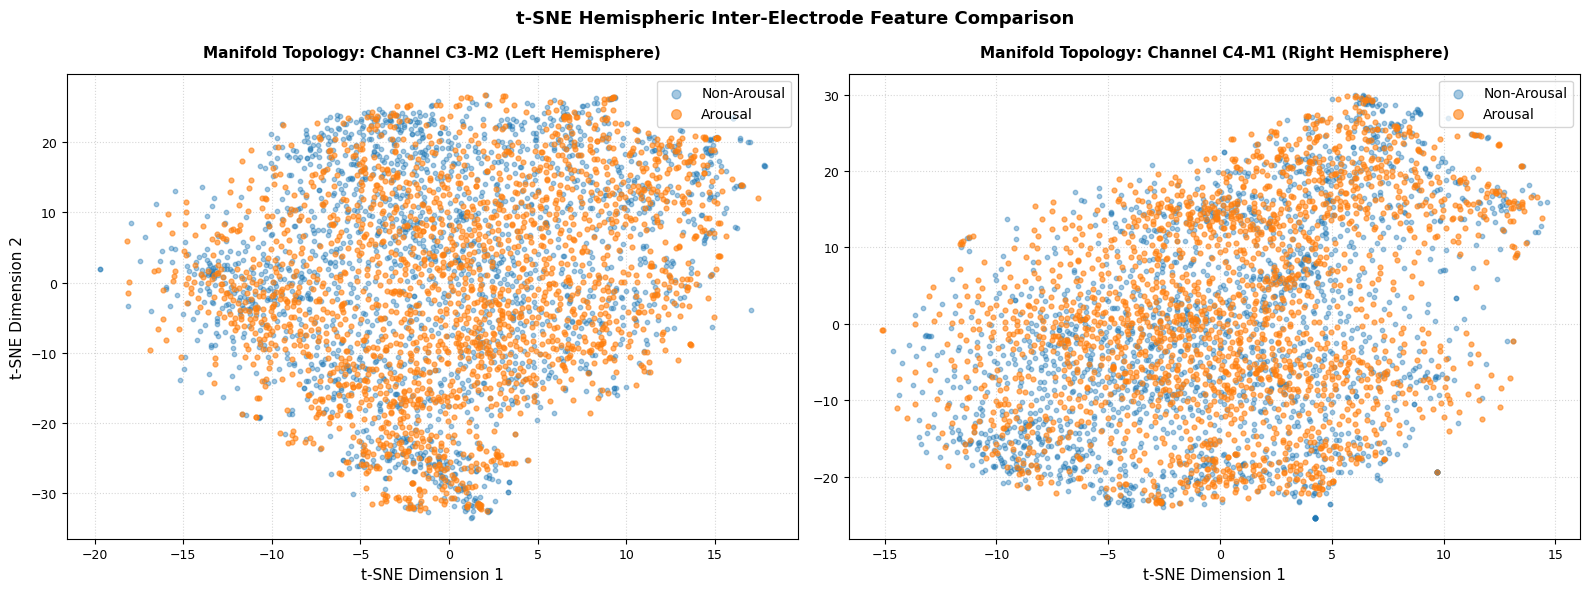

In [62]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

n_samples_per_class = 2000

idx_arousal = np.random.choice(len(arousals), n_samples_per_class, replace=False)
idx_non = np.random.choice(len(non_arousals), n_samples_per_class, replace=False)

# Shape of subsets: (2000, 2, 80, 53)
sub_arousal = arousals[idx_arousal]
sub_non = non_arousals[idx_non]

# Combine into features and labels
X_combined = np.vstack([sub_arousal, sub_non]) # Shape: (4000, 2, 80, 53)
y = np.hstack([np.ones(n_samples_per_class), np.zeros(n_samples_per_class)])

# --- 2. Compute t-SNE Per Electrode ---
electrodes = ["C3-M2 (Left Hemisphere)", "C4-M1 (Right Hemisphere)"]

# Setup side-by-side subplots elegantly
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ch in [0, 1]:
    print(f"[*] Extracting and flattening features for Electrode {ch} ({electrodes[ch]})...")
    
    # Isolate the specific channel and flatten the 2D STFT grid (80x53) to 1D (4240,)
    # Input: (4000, 2, 80, 53) -> Slice channel: (4000, 80, 53) -> Flatten: (4000, 4240)
    X_ch = X_combined[:, ch, :, :].reshape(X_combined.shape[0], -1)
    
    # Scale features (Essential for t-SNE distance metrics)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_ch)
    
    print(f"[*] Computing t-SNE embedding for Electrode {ch}...")
    tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1, init='pca')
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Separate the projections for custom visualization styling
    tsne_arousal = X_tsne[y == 1]
    tsne_non = X_tsne[y == 0]
    
    # Plot on the corresponding subplot axis
    ax = axes[ch]
    ax.scatter(tsne_non[:, 0], tsne_non[:, 1], color='tab:blue', alpha=0.4, s=10, label='Non-Arousal')
    ax.scatter(tsne_arousal[:, 0], tsne_arousal[:, 1], color='tab:orange', alpha=0.6, s=12, label='Arousal')
    
    ax.set_title(f'Manifold Topology: Channel {electrodes[ch]}', weight='semibold', pad=12)
    ax.set_xlabel('t-SNE Dimension 1')
    if ch == 0:
        ax.set_ylabel('t-SNE Dimension 2')
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', markerscale=2)

fig.suptitle('t-SNE Hemispheric Inter-Electrode Feature Comparison', fontsize=13, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig('stft_inter_electrode_tsne.png', dpi=300)
plt.show()